In [3]:
import pandas as pd

df=pd.read_excel(r'F:\strwaberry images\final_dataset_back_setup_down_plant2.xlsx')
print(df.head())

   Station ID           Date Time  Soil Temp (C)  Temp @ 60cm (C)  \
0         260 2025-12-12 16:45:00          15.60            21.55   
1         260 2025-12-12 17:00:00          15.67            21.67   
2         260 2025-12-12 17:15:00          15.74            19.34   
3         260 2025-12-12 17:30:00          15.78            15.69   
4         260 2025-12-12 17:45:00          15.81            12.87   

   Temp @ 2m (C)  Temp @ 10m (C)  Relative Humidity (%)  Dew Point Temp (C)  \
0          21.69           21.16                  30.44                3.58   
1          20.78           21.03                  39.15                6.39   
2          18.13           21.10                  48.86                7.21   
3          15.99           18.07                  59.45                8.10   
4          14.28           15.60                  64.40                7.66   

   Rainfall Amount (in)  Wind Speed (mph)  Wind Direction (deg)  \
0                   0.0              3.45  

In [4]:
df["G"] = df["Image_green_pixels"] / df["Image_green_pixels"].max()

In [5]:
df = df.dropna(subset=['Image_name'])

In [6]:
G_true = df["G"].values

In [7]:
from scipy.optimize import curve_fit
import numpy as np

def logistic(t, r, K, G0):
    return K / (1 + ((K-G0)/G0) * np.exp(-r*t))

t = np.arange(len(df))
G = df["G"].values

params, _ = curve_fit(logistic, t, G, maxfev=5000)
r, K, G0 = params

C:\Users\rohan\AppData\Local\Temp\ipykernel_12496\860104605.py:5: RuntimeWarning: overflow encountered in exp
  return K / (1 + ((K-G0)/G0) * np.exp(-r*t))


In [9]:
def logistic(t, r, K, G0):
    return K / (1 + ((K - G0)/G0) * np.exp(-r * t))

t = np.arange(len(df))

G_ode = logistic(t, r, K, G0)

In [26]:
residual = G_true - G_ode

Text(0, 0.5, 'Green canopy area')

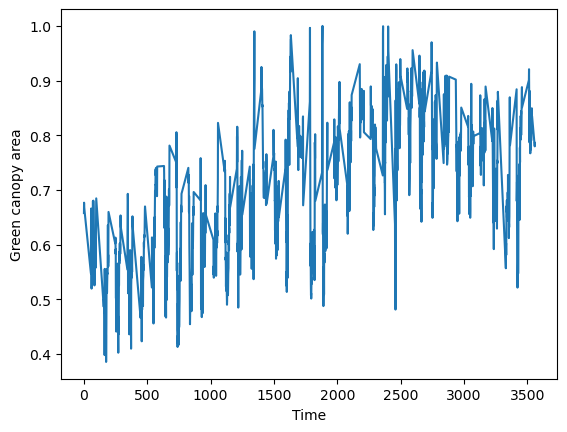

In [10]:
from matplotlib import pyplot as plt
plt.plot(df.index, df["G"])
plt.xlabel("Time")
plt.ylabel("Green canopy area")

In [21]:
weather_features = [
"Temp @ 2m (C)",
"Relative Humidity (%)",
"Solar Radiation (w/m2)",
"Wind Speed (mph)",
"Solar Radiation (w/m2)",
"Rainfall Amount (in)",
"GDD(Tbase=7)",
"Tmax (Temp @ 2m)",	
"Tmin (Temp @ 2m)"
]

In [23]:
X_weather = df[weather_features]
X_weather

,Temp @ 2m (C),Relative Humidity (%),Solar Radiation (w/m2),Wind Speed (mph),Solar Radiation (w/m2),Rainfall Amount (in),GDD(Tbase=7),Tmax (Temp @ 2m),Tmin (Temp @ 2m)
0,21.69,30.44,128.50,3.45,128.50,0.00,7.345,21.69,7.0
1,20.78,39.15,89.40,2.14,89.40,0.00,7.345,21.69,7.0
2,18.13,48.86,49.28,0.61,49.28,0.00,7.345,21.69,7.0
55,3.40,94.00,0.01,0.98,0.01,0.00,9.045,25.09,7.0
56,3.36,94.00,0.02,1.22,0.02,0.00,9.045,25.09,7.0
...,...,...,...,...,...,...,...,...,...
3535,7.68,93.40,121.40,4.33,121.40,0.01,3.545,14.09,7.0
3536,7.78,93.40,111.40,3.28,111.40,0.01,3.545,14.09,7.0
3537,7.73,93.50,76.42,4.12,76.42,0.00,3.545,14.09,7.0
3558,5.91,87.50,0.08,3.61,0.08,0.00,3.545,14.09,7.0


In [24]:
cols = [
    'Soil Temp (C)',
    'Temp @ 60cm (C)',
    'Temp @ 2m (C)',
    'Temp @ 10m (C)',
    'Relative Humidity (%)',
    'Dew Point Temp (C)',
    'Rainfall Amount (in)',
    'Wind Speed (mph)',
    'Wind Direction (deg)',
    'Solar Radiation (w/m2)'
]

X_weather = X_weather.apply(pd.to_numeric, errors='coerce')
X_weather

,Temp @ 2m (C),Relative Humidity (%),Solar Radiation (w/m2),Wind Speed (mph),Solar Radiation (w/m2),Rainfall Amount (in),GDD(Tbase=7),Tmax (Temp @ 2m),Tmin (Temp @ 2m)
0,21.69,30.44,128.50,3.45,128.50,0.00,7.345,21.69,7.0
1,20.78,39.15,89.40,2.14,89.40,0.00,7.345,21.69,7.0
2,18.13,48.86,49.28,0.61,49.28,0.00,7.345,21.69,7.0
55,3.40,94.00,0.01,0.98,0.01,0.00,9.045,25.09,7.0
56,3.36,94.00,0.02,1.22,0.02,0.00,9.045,25.09,7.0
...,...,...,...,...,...,...,...,...,...
3535,7.68,93.40,121.40,4.33,121.40,0.01,3.545,14.09,7.0
3536,7.78,93.40,111.40,3.28,111.40,0.01,3.545,14.09,7.0
3537,7.73,93.50,76.42,4.12,76.42,0.00,3.545,14.09,7.0
3558,5.91,87.50,0.08,3.61,0.08,0.00,3.545,14.09,7.0


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_weather_scaled = scaler.fit_transform(X_weather.values)
X_weather_scaled

array([[ 0.65468552, -1.85547547, -0.7202695 , ..., -0.35759942,
        -0.03570418, -0.78856067],
       [ 0.51850024, -1.43165666, -0.91420986, ..., -0.35759942,
        -0.03570418, -0.78856067],
       [ 0.12191672, -0.95917897, -1.11320954, ..., -0.35759942,
        -0.03570418, -0.78856067],
       ...,
       [-1.43448653,  1.21295329, -0.97859211, ..., -1.45534778,
        -1.58916507, -0.78856067],
       [-1.7068571 ,  0.92100003, -1.35724702, ..., -1.45534778,
        -1.58916507, -0.78856067],
       [-1.79515306,  0.95992713, -1.35759423, ..., -1.45534778,
        -1.58916507, -0.78856067]], shape=(1557, 9))

In [ ]:
import torch

X_tensor = torch.tensor(X_weather_scaled, dtype=torch.float32)
y_tensor = torch.tensor(residual, dtype=torch.float32).unsqueeze(1)

In [ ]:
import torch.nn as nn

class ResidualNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
model = ResidualNet(input_dim=X_tensor.shape[1])

In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 500

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(X_tensor)

    loss = criterion(pred, y_tensor)

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

In [ ]:
residual_pred = model(X_tensor).detach().numpy().flatten()

G_pred = G_ode + residual_pred

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(G_true, label="True Growth")

plt.plot(G_ode, label="Logistic ODE")

plt.plot(G_pred, label="ODE + Residual NN")

plt.legend()

plt.show()